# Exploratory Data Analysis and Data Cleaning of E-commerce Transactions

###  SECTION 1 — INTRODUCTION

### Introduction

This analysis focuses on the E-commerce Transactions dataset (Online Retail dataset). The goal of this task is to understand the structure of the dataset before performing any cleaning or analysis and documentation of decisions.
. The objective is to clean raw data, handle missing values, standardize formats, and extract meaningful insights through exploratory data analysis and visualization.

In this stage, we will:
- Load and inspect the dataset
- Identify data types and structure
- Detect missing values
- Distinguish numerical and categorical features
- Identify potential unique identifiers

This step is important because proper understanding of the dataset ensures accurate and efficient data cleaning and analysis in later stages.

### SECTION 2 — DATA LOADING

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### SECTION 3 — DATA UNDERSTANDING

In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
### SUMMARY STATISTICS (NUMERICAL INSIGHT)
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
## CHECK MISSING VALUES
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# DATA TYPES AND COLUMN NAMES
# df.dtypes
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
# NUMERICAL FEATURES
df.select_dtypes(include=['number']).columns

Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')

In [10]:
# CATEGORICAL FEATURES
df.select_dtypes(include=['object']).columns

Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')

In [11]:
# CHECK UNIQUE VALUES (FOR POSSIBLE PRIMARY KEYS)
df.nunique().sort_values(ascending=False)

InvoiceNo      25900
InvoiceDate    23260
CustomerID      4372
Description     4223
StockCode       4070
UnitPrice       1630
Quantity         722
Country           38
dtype: int64

### Dataset Overview
1. Rows: 541909
2. Columns: 8
3. Numerical features: 'Quantity', 'UnitPrice', 'CustomerID'
4. Categorical features: 'InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object'
5. Potential primary keys: The most suitable primary key for this dataset is a composite key made up of: InvoiceNo,StockCode
### Reason:
Individually, neither column is unique:
- InvoiceNo repeats because one invoice can contain multiple products.
- StockCode repeats because products are purchased many times.

However, the combination of InvoiceNo and StockCode uniquely identifies each transaction line item, making it the best candidate for a primary key.

## Dataset Description (E-commerce Transactions)

This dataset contains transactional data from an online retail store. It includes information about products purchased, quantities, unit prices, customers, countries, and invoice details.

The dataset can be used to analyze customer purchasing behavior, sales performance, and revenue distribution across regions.

### SECTION 4 — DATA CLEANING (MOST IMPORTANT SECTION)

In [12]:
###  Missing Values
missing = df.isnull().sum()
missing

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
# DROP NULL CUSTOMER ID (IMPORTANT)
df = df.dropna(subset=['CustomerID'])

In [14]:
#  DROP NEGATIVE / INVALID VALUES
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [15]:
### Duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [16]:
# STANDARDIZE COLUMN NAMES
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

In [17]:
### FIX DATE FORMAT
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

In [18]:
# ADD REVENUE COLUMN
df['revenue'] = df['quantity'] * df['unitprice']

In [19]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'revenue'],
      dtype='object')

In [20]:
### Data Validation (THIS MAKES YOU STAND OUT)
df = df[df['quantity'] > 0]
df = df[df['unitprice'] > 0]

In [21]:
# CLEANING SUMMARY TABLE (VERY IMPORTANT)
summary = pd.DataFrame({
    "Issue": ["Missing Values", "Duplicates", "Invalid Values", "Standardization","Convertion", "Creation"],
    "Action Taken": ["Removed rows with missing CustomerID", "Removed duplicate records", "Filtered invalid Quantity and UnitPrice values",
                     "Standardized column names","Converted InvoiceDate to datetime format","Created Revenue column for analysis" ]
})

summary

,Issue,Action Taken
0,Missing Values,Removed rows with missing CustomerID
1,Duplicates,Removed duplicate records
2,Invalid Values,Filtered invalid Quantity and UnitPrice values
3,Standardization,Standardized column names
4,Convertion,Converted InvoiceDate to datetime format
5,Creation,Created Revenue column for analysis


### SECTION 5 — EDA 

In [22]:
### 1. Top products Sold
df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: quantity, dtype: int64

In [23]:
### 2. Top countries by revenue
df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: revenue, dtype: float64

<Axes: xlabel='month'>

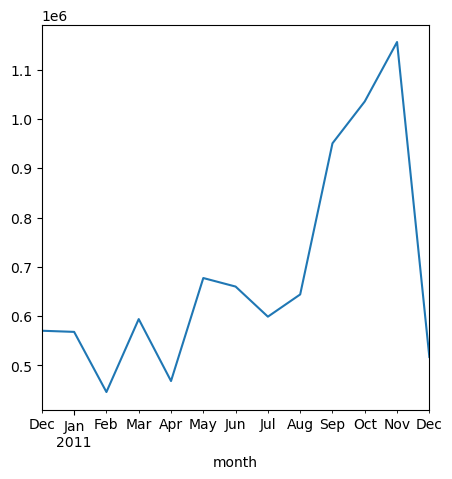

In [24]:
# 3 MONTHLY SALES TREND
df['month'] = df['invoicedate'].dt.to_period('M')
df.groupby('month')['revenue'].sum().plot(kind='line', figsize=(5,5))

In [24]:
### 4. Customer behavior
df.groupby('customerid')['revenue'].sum().sort_values(ascending=False).head(10)

customerid
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: revenue, dtype: float64

In [25]:
### 5. AVERAGE ORDER VALUE
df['invoice_value'] = df.groupby('invoiceno')['revenue'].transform('sum')
df['invoice_value'].mean()

np.float64(746.4359619549163)

### SECTION 6 — VISUALIZATION 

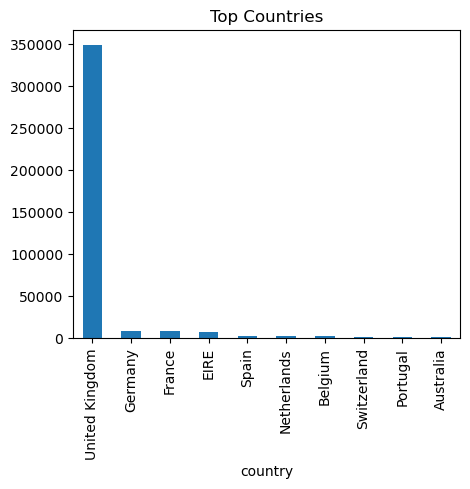

In [30]:
### Top Countries
df['country'].value_counts().head(10).plot(kind='bar',figsize=(5,4))
plt.title("Top Countries")
plt.show()

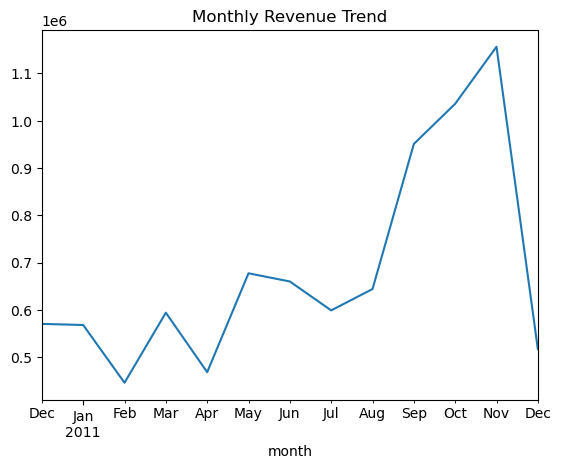

In [27]:
### Monthly Revenue Trend
df.groupby('month')['revenue'].sum().plot()
plt.title("Monthly Revenue Trend")
plt.show()

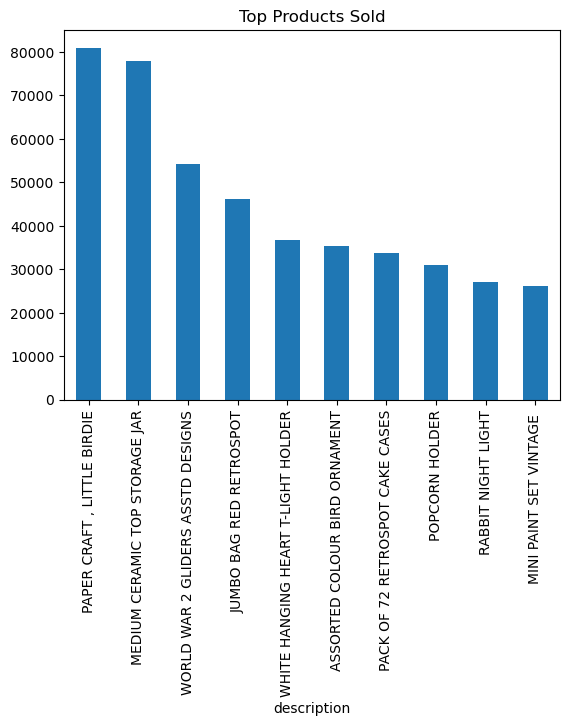

In [28]:
# TOP PRODUCTS (BAR)
df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Products Sold")
plt.show()

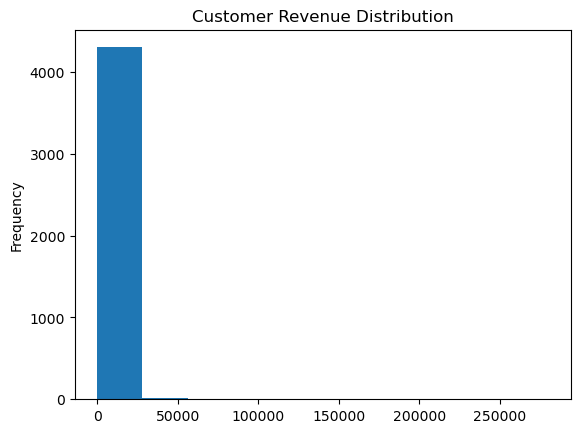

In [29]:
# CUSTOMER DISTRIBUTION (HISTOGRAM)
df.groupby('customerid')['revenue'].sum().plot(kind='hist')
plt.title("Customer Revenue Distribution")
plt.show()

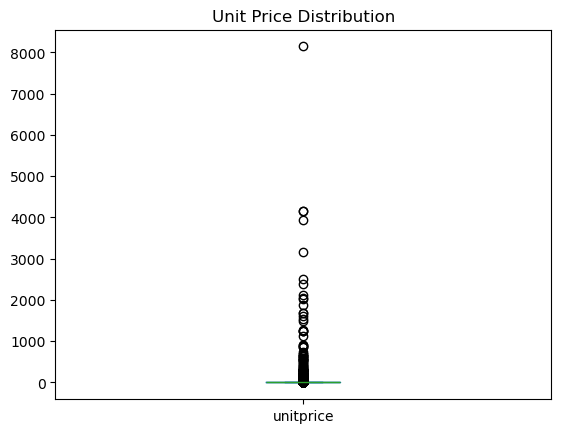

In [30]:
### Price Distribution
df['unitprice'].plot(kind='box')
plt.title("Unit Price Distribution")
plt.show()

### SECTION 7 Key Insights

1. The United Kingdom dominates revenue generation, contributing the majority of total sales.

2. A small percentage of customers generate most of the revenue, showing a strong Pareto distribution.

3. Sales show clear monthly fluctuations, indicating seasonal buying behavior.

4. Certain products account for disproportionately high quantities sold, showing product concentration.

5. Average order value suggests that customers frequently make bulk purchases rather than single-item transactions.

## Conclusion

This analysis successfully cleaned and explored the E-commerce Transactions dataset. Key insights were extracted regarding customer behavior, revenue distribution, and product performance.

The dataset is now structured and ready for further advanced analytics such as predictive modeling or customer segmentation.

In [31]:
df.to_csv("cleaned_retail_data.csv", index=False)